<a href="https://colab.research.google.com/github/abidahnisaa/Project_Breast_Cancer_Poster_Presentation_UNS/blob/main/1.5%20Graphic%2C_Filtered_continued.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load full dataset
df = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/depmap_crispr_26Q1.csv"
)

# Metadata dan gene columns
meta_cols = [
    "model_id",
    "cell_line_name",
    "stripped_cell_line_name",
    "oncotree_lineage",
    "oncotree_primary_disease",
    "oncotree_subtype"
]

gene_cols = df.columns[6:]
gene_df = df[gene_cols]

# Hitung essential fraction dan median gene effect
essential_threshold = -0.5

essential_fraction = (gene_df < essential_threshold).mean(axis=0) * 100
median_effect = gene_df.median(axis=0)

plot_df = pd.DataFrame({
    "Gene": gene_cols,
    "Percent_Essential": essential_fraction.values,
    "Median_Gene_Effect": median_effect.values
})

# Kategori: pan-essential vs non-pan-essential
plot_df["Category"] = "Other genes"
plot_df.loc[
    plot_df["Percent_Essential"] > 90,
    "Category"
] = "Pan-essential/common essential"

# Cek jumlah
print(plot_df["Category"].value_counts())
display(plot_df.head())

Category
Other genes                       17557
Pan-essential/common essential      974
Name: count, dtype: int64


,Gene,Percent_Essential,Median_Gene_Effect,Category
0,A1BG,0.082781,0.008099,Other genes
1,AASS,0.165563,0.035574,Other genes
2,ABCA10,0.082781,0.080464,Other genes
3,ABCA7,0.082781,0.072709,Other genes
4,ABCA8,0.082781,-0.011447,Other genes


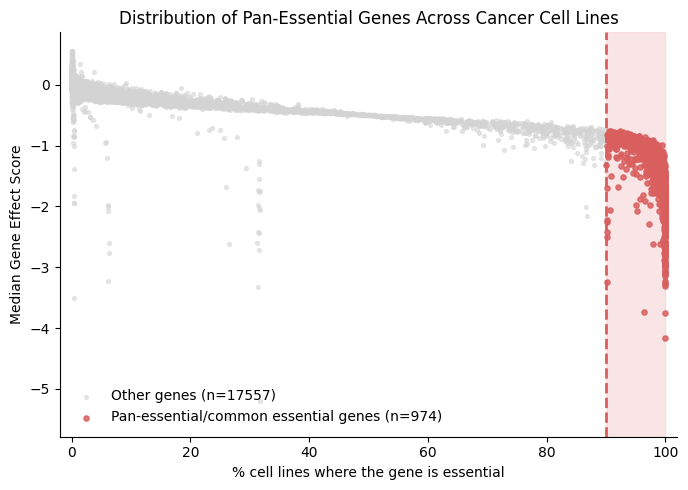

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

# Background area untuk pan-essential region
ax.axvspan(
    90,
    100,
    color="#f4cccc",
    alpha=0.5
)

# Other genes
other = plot_df[plot_df["Category"] == "Other genes"]
ax.scatter(
    other["Percent_Essential"],
    other["Median_Gene_Effect"],
    s=8,
    color="lightgray",
    alpha=0.5,
    label=f"Other genes (n={len(other)})"
)

# Pan-essential genes
pan = plot_df[plot_df["Category"] == "Pan-essential/common essential"]
ax.scatter(
    pan["Percent_Essential"],
    pan["Median_Gene_Effect"],
    s=14,
    color="#d95f5f",
    alpha=0.85,
    label=f"Pan-essential/common essential genes (n={len(pan)})"
)

# Threshold line
ax.axvline(
    x=90,
    linestyle="--",
    color="#d95f5f",
    linewidth=2
)

# Labels
ax.set_xlabel("% cell lines where the gene is essential")
ax.set_ylabel("Median Gene Effect Score")
ax.set_title("Distribution of Pan-Essential Genes Across Cancer Cell Lines")

# Style seperti paper
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-2, 102)

# Legend
ax.legend(frameon=False, loc="lower left")

plt.tight_layout()

# Save
plt.savefig(
    "/content/drive/MyDrive/Breast Cancer Model/pan_essential_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD DATA
# ==============================

# Full DepMap CRISPR dataset
df_all = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/depmap_crispr_26Q1.csv"
)

# Breast filtered dataset: breast-only + pan-essential genes removed
df_breast_filtered = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/breast_filtered_no_panessential.csv"
)

# Pan-essential gene list
pan_essential_df = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/pan_essential_genes.csv"
)

In [12]:
# ==============================
# 2. DEFINE METADATA AND GENE COLUMNS
# ==============================

meta_cols = [
    "model_id",
    "cell_line_name",
    "stripped_cell_line_name",
    "oncotree_lineage",
    "oncotree_primary_disease",
    "oncotree_subtype"
]

gene_cols_all = df_all.columns[6:]
gene_cols_breast_filtered = df_breast_filtered.columns[6:]

print("All genes:", len(gene_cols_all))
print("Genes after pan-essential removal in breast dataset:", len(gene_cols_breast_filtered))
print("Pan-essential genes:", len(pan_essential_df))

All genes: 18531
Genes after pan-essential removal in breast dataset: 17557
Pan-essential genes: 974


In [16]:
# ==============================
# 3. CALCULATE WHOLE-DATASET METRICS
# ==============================

gene_df_all = df_all[gene_cols_all]

# X-axis: % cell lines where gene is essential
essential_threshold < -0.5

percent_essential = (
    (gene_df_all < essential_threshold)
    .mean(axis=0)
    * 100
)

# Y-axis: median gene effect score across all cancer cell lines
median_gene_effect = gene_df_all.median(axis=0)

plot_df = pd.DataFrame({
    "Gene": gene_cols_all,
    "Percent_Essential": percent_essential.values,
    "Median_Gene_Effect": median_gene_effect.values
})

display(plot_df.head())

,Gene,Percent_Essential,Median_Gene_Effect
0,A1BG,0.082781,0.008099
1,AASS,0.165563,0.035574
2,ABCA10,0.082781,0.080464
3,ABCA7,0.082781,0.072709
4,ABCA8,0.082781,-0.011447


In [17]:
# ==============================
# 4. DEFINE CATEGORIES
# ==============================

pan_gene_list = pan_essential_df["Gene"].tolist()
breast_filtered_gene_list = list(gene_cols_breast_filtered)

plot_df["Category"] = "Other genes"

# Pan-essential genes
plot_df.loc[
    plot_df["Gene"].isin(pan_gene_list),
    "Category"
] = "Pan-essential/common essential"

# Breast-essential candidate genes after pan-essential removal
plot_df.loc[
    plot_df["Gene"].isin(breast_filtered_gene_list),
    "Category"
] = "Breast candidate genes"

print(plot_df["Category"].value_counts())

Category
Breast candidate genes            17557
Pan-essential/common essential      974
Name: count, dtype: int64


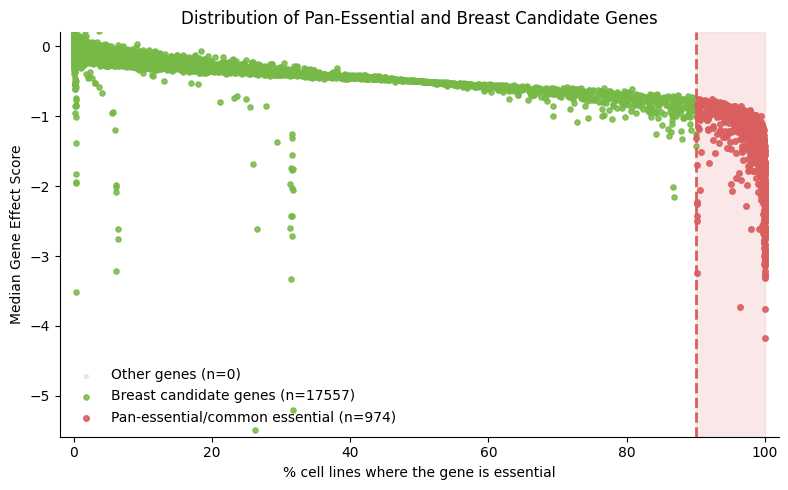

In [18]:
# ==============================
# 5. PLOT
# ==============================

fig, ax = plt.subplots(figsize=(8, 5))

# Highlight pan-essential region
ax.axvspan(
    90,
    100,
    color="#f4cccc",
    alpha=0.45
)

# Plot order: other first, breast candidate second, pan-essential last
categories = [
    ("Other genes", "lightgray", 8, 0.45),
    ("Breast candidate genes", "#76b947", 14, 0.85),
    ("Pan-essential/common essential", "#d95f5f", 16, 0.9)
]

for category, color, size, alpha in categories:
    subset = plot_df[plot_df["Category"] == category]
    ax.scatter(
        subset["Percent_Essential"],
        subset["Median_Gene_Effect"],
        s=size,
        color=color,
        alpha=alpha,
        label=f"{category} (n={len(subset)})"
    )

# Threshold line for pan-essential
ax.axvline(
    x=90,
    linestyle="--",
    color="#d95f5f",
    linewidth=2
)

# Labels
ax.set_xlabel("% cell lines where the gene is essential")
ax.set_ylabel("Median Gene Effect Score")
ax.set_title("Distribution of Pan-Essential and Breast Candidate Genes")

# Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(-2, 102)
ax.set_ylim(plot_df["Median_Gene_Effect"].min() - 0.1, 0.2)

ax.legend(
    frameon=False,
    loc="lower left"
)

plt.tight_layout()

# Save figure
plt.savefig(
    "/content/drive/MyDrive/Breast Cancer Model/pan_vs_breast_candidate_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD DATA
# ==============================

df_all = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/depmap_crispr_26Q1.csv"
)

pan_essential_df = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/pan_essential_genes.csv"
)

breast_essential_df = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/essentiality_mean_dependency_scores_filtered_threshold.csv"
)

In [20]:
# ==============================
# 2. PREPARE GENE DATA
# ==============================

gene_cols = df_all.columns[6:]
gene_df = df_all[gene_cols]

essential_threshold = -0.5

percent_essential = (gene_df < essential_threshold).mean(axis=0) * 100
median_gene_effect = gene_df.median(axis=0)

plot_df = pd.DataFrame({
    "Gene": gene_cols,
    "Percent_Essential": percent_essential.values,
    "Median_Gene_Effect": median_gene_effect.values
})

In [65]:
# ==============================
# 2. PREPARE GENE DATA
# ==============================

gene_cols = df_all.columns[6:]
gene_df = df_all[gene_cols]

essential_threshold = -0.5

percent_essential = (gene_df < essential_threshold).mean(axis=0) * 100
mean_gene_dependency = gene_df.median(axis=0)

plot_df = pd.DataFrame({
    "Gene": gene_cols,
    "Percent_Essential": percent_essential.values,
    "Mean_Gene_Dependency": mean_gene_dependency.values
})

In [82]:
# ==============================
# 3. DEFINE CATEGORIES
# ==============================

pan_gene_list = pan_essential_df["Gene"].tolist()
breast_essential_gene_list = breast_essential_df["Gene"].tolist()

plot_df["Category"] = "Other genes"

plot_df.loc[
    plot_df["Gene"].isin(pan_gene_list),
    "Category"
] = "Pan-essential/common essential"

plot_df.loc[
    plot_df["Gene"].isin(breast_essential_gene_list),
    "Category"
] = "Breast-essential genes"

print(plot_df["Category"].value_counts())

Category
Other genes                       16824
Pan-essential/common essential      974
Breast-essential genes              733
Name: count, dtype: int64


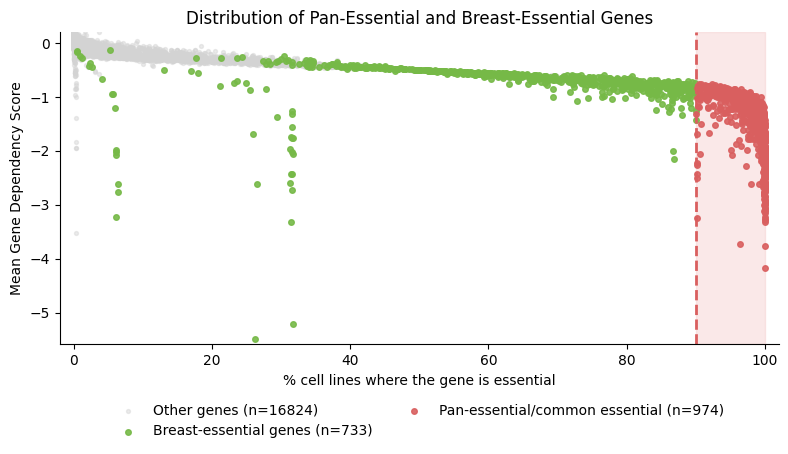

In [84]:
# ==============================
# 4. PLOT
# ==============================

fig, ax = plt.subplots(figsize=(8, 5))

# Pan-essential region
ax.axvspan(
    90,
    100,
    color="#f4cccc",
    alpha=0.45
)

categories = [
    ("Other genes", "lightgray", 8, 0.45),
    ("Breast-essential genes", "#76b947", 16, 0.9),
    ("Pan-essential/common essential", "#d95f5f", 16, 0.9)
]

for category, color, size, alpha in categories:
    subset = plot_df[plot_df["Category"] == category]
    ax.scatter(
        subset["Percent_Essential"],
        subset["Mean_Gene_Dependency"],
        s=size,
        color=color,
        alpha=alpha,
        label=f"{category} (n={len(subset)})",
    )

ax.axvline(
    x=90,
    linestyle="--",
    color="#d95f5f",
    linewidth=2
)

ax.set_xlabel("% cell lines where the gene is essential")
ax.set_ylabel("Mean Gene Dependency Score")
ax.set_title("Distribution of Pan-Essential and Breast-Essential Genes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(-2, 102)
ax.set_ylim(plot_df["Mean_Gene_Dependency"].min() - 0.1, 0.2)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(
    "/content/drive/MyDrive/Breast Cancer Model/Distribution_Essential_Gene1.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [26]:
priority_targets = plot_df[
    (plot_df["Category"] == "Breast-essential genes") &
    (plot_df["Percent_Essential"] < 40) &
    (plot_df["Median_Gene_Effect"] < -1)
]

print(priority_targets.shape)

display(
    priority_targets.sort_values(
        "Median_Gene_Effect"
    ).head(50)
)

(26, 4)


,Gene,Percent_Essential,Median_Gene_Effect,Category
13498,RPL15,26.241722,-5.483935,Breast-essential genes
13851,SNRPD3,31.705298,-5.203385,Breast-essential genes
13503,RPL21,31.456954,-3.324975,Breast-essential genes
11644,PRIM2,6.125828,-3.219029,Breast-essential genes
3349,DNA2,6.374172,-2.761230,Breast-essential genes
12799,RPL6,31.539735,-2.719249,Breast-essential genes
8836,RPSA,26.490066,-2.610926,Breast-essential genes
5191,DCAF13,6.374172,-2.605811,Breast-essential genes
3452,EEF1A1,31.291391,-2.603004,Breast-essential genes
13505,RPL23A,31.539735,-2.429723,Breast-essential genes


In [27]:
priority_targets.to_csv(
    "/content/drive/MyDrive/Breast Cancer Model/priority_targets.csv",
    index=False)

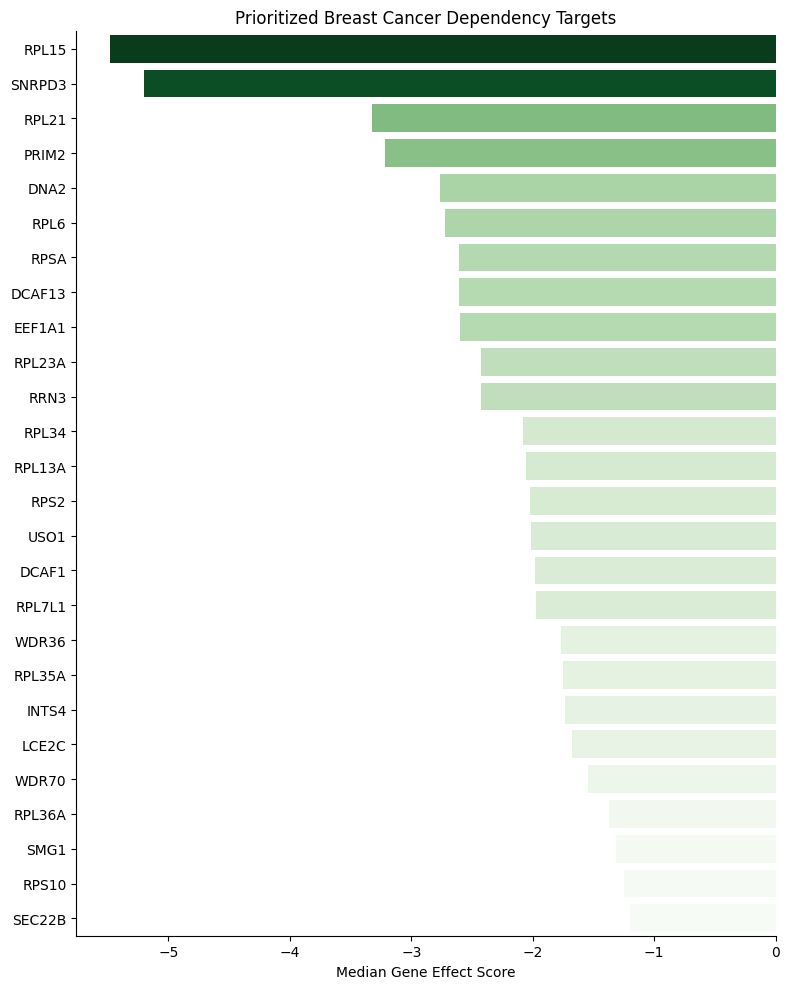

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort strongest dependency first
priority_targets_sorted = (
    priority_targets
    .sort_values("Median_Gene_Effect", ascending=True)
)

plt.figure(figsize=(8,10))

sns.barplot(
    data=priority_targets_sorted,
    y="Gene",
    x="Median_Gene_Effect",
    hue="Median_Gene_Effect",
    palette="Greens_r",
    dodge=False,
    legend=False
)


plt.xlabel("Median Gene Effect Score")
plt.ylabel("")
plt.title("Prioritized Breast Cancer Dependency Targets")

# Clean style
sns.despine()

plt.tight_layout()

# Save
plt.savefig(
    "/content/drive/MyDrive/Breast Cancer Model/priority_targets_horizontal_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

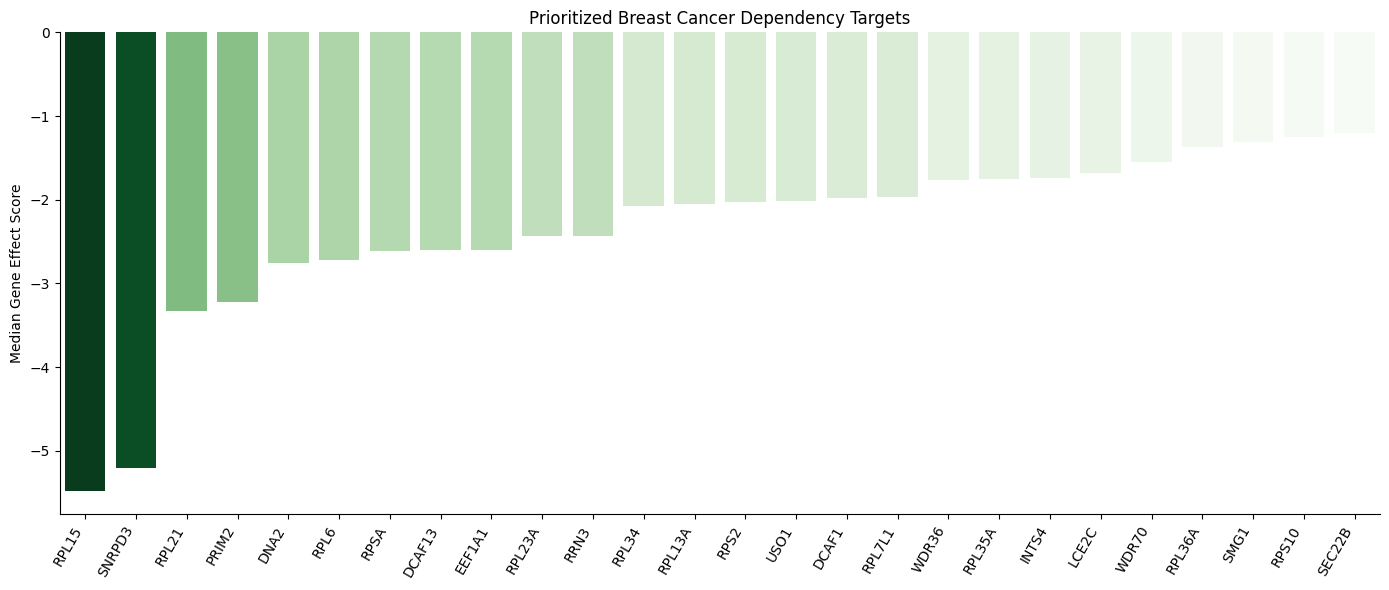

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort strongest dependency first
priority_targets_sorted = (
    priority_targets
    .sort_values("Median_Gene_Effect")
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=priority_targets_sorted,
    x="Gene",
    y="Median_Gene_Effect",
    hue="Median_Gene_Effect",
    palette="Greens_r",
    dodge=False,
    legend=False
)


# Labels
plt.xlabel("")
plt.ylabel("Median Gene Effect Score")
plt.title("Prioritized Breast Cancer Dependency Targets")

# Rotate gene names
plt.xticks(
    rotation=60,
    ha="right"
)

# Clean style
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    "/content/drive/MyDrive/Breast Cancer Model/priority_targets_vertical_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Grafik Distribusi

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD DATA
# ==============================

df_all = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/depmap_crispr_26Q1.csv"
)

pan_essential_df = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/pan_essential_genes.csv"
)

breast_essential_df = pd.read_csv(
    "/content/drive/MyDrive/Breast Cancer Model/essentiality_mean_dependency_scores_filtered_threshold.csv"
)
priority_targets_df = pd.read_csv("/content/drive/MyDrive/Breast Cancer Model/priority_targets.csv")

In [77]:
# ==============================
# 2. PREPARE GENE DATA
# ==============================

gene_cols = df_all.columns[6:]
gene_df = df_all[gene_cols]

essential_threshold = -0.5

percent_essential = (gene_df < essential_threshold).mean(axis=0) * 100
mean_gene_dependency = gene_df.median(axis=0)

plot_df = pd.DataFrame({
    "Gene": gene_cols,
    "Percent_Essential": percent_essential.values,
    "Mean_Gene_Dependency": mean_gene_dependency.values
})

In [78]:
# ==============================
# 3. DEFINE CATEGORIES
# ==============================

pan_gene_list = pan_essential_df["Gene"].tolist()
breast_essential_gene_list = breast_essential_df["Gene"].tolist()

plot_df["Category"] = "Other genes"

plot_df.loc[
    plot_df["Gene"].isin(pan_gene_list),
    "Category"
] = "Pan-essential/common essential"

plot_df.loc[
    plot_df["Gene"].isin(breast_essential_gene_list),
    "Category"
] = "Breast-essential genes"

# Priority targets
priority_gene_list = priority_targets["Gene"].tolist()

plot_df.loc[
    plot_df["Gene"].isin(priority_gene_list),
    "Category"
] = "Priority targets"

print(plot_df["Category"].value_counts())

Category
Other genes                       16824
Pan-essential/common essential      974
Breast-essential genes              707
Priority targets                     26
Name: count, dtype: int64


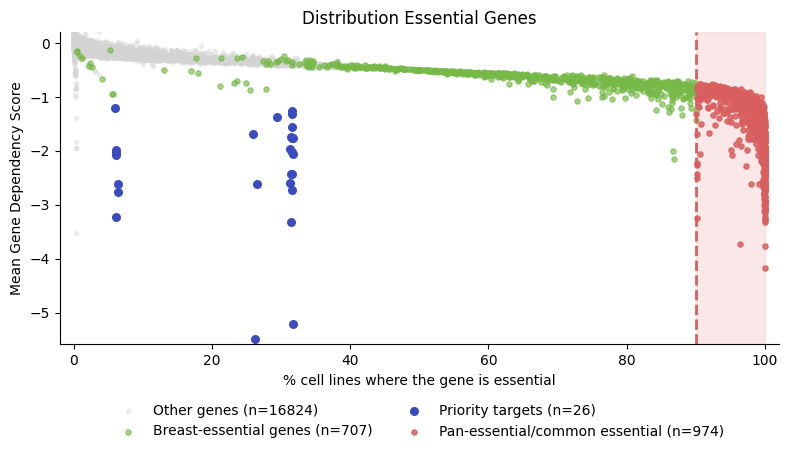

In [80]:
# ==============================
# 4. PLOT
# ==============================

fig, ax = plt.subplots(figsize=(8, 5))

# Pan-essential region
ax.axvspan(
    90,
    100,
    color="#f4cccc",
    alpha=0.45
)

categories = [
    ("Other genes", "lightgray", 8, 0.35),
    ("Breast-essential genes", "#76b947", 14, 0.65),
    ("Priority targets", "#3b4cc0", 30, 1),
    ("Pan-essential/common essential", "#d95f5f", 14, 0.85)
]

for category, color, size, alpha in categories:
    subset = plot_df[plot_df["Category"] == category]
    ax.scatter(
        subset["Percent_Essential"],
        subset["Mean_Gene_Dependency"],
        s=size,
        color=color,
        alpha=alpha,
        label=f"{category} (n={len(subset)})"
    )

ax.axvline(
    x=90,
    linestyle="--",
    color="#d95f5f",
    linewidth=2
)

ax.set_xlabel("% cell lines where the gene is essential")
ax.set_ylabel("Mean Gene Dependency Score")
ax.set_title("Distribution Essential Genes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(-2, 102)
ax.set_ylim(plot_df["Mean_Gene_Dependency"].min() - 0.1, 0.2)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(
    "/content/drive/MyDrive/Breast Cancer Model/Distribution Essential Gene.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()